In [3]:
import numpy as np
import pandas as pd
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import sys
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import time
from tqdm.notebook import tqdm, trange
from torch import optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


In [4]:
# MNIST Dataset download and load

torch.manual_seed(42)

train_transforms = transforms.Compose([
    transforms.Resize((28, 28)),    
    transforms.ToTensor()
])

eval_transforms = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(root='data', train=True, download=True, transform=train_transforms)
valid_dataset = datasets.MNIST(root='data', train=True, download=True, transform=eval_transforms)
test_dataset = datasets.MNIST(root='data', train=False, download=True, transform=eval_transforms)

train_mask = (train_dataset.targets == 0) | (train_dataset.targets == 1)
test_mask = (test_dataset.targets == 0) | (test_dataset.targets == 1)

train_dataset.data = train_dataset.data[train_mask]
train_dataset.targets = train_dataset.targets[train_mask]
valid_dataset.data = valid_dataset.data[train_mask]
valid_dataset.targets = valid_dataset.targets[train_mask]
test_dataset.data = test_dataset.data[test_mask]
test_dataset.targets = test_dataset.targets[test_mask]

val_frac = 0.3
val_size = int(val_frac * len(train_dataset))
train_size = len(train_dataset) - val_size

split_perm = torch.randperm(len(train_dataset), generator=torch.Generator().manual_seed(42))
val_indices = split_perm[:val_size]
train_indices = split_perm[val_size:]

train_subset = torch.utils.data.Subset(train_dataset, train_indices.tolist())
valid_subset = torch.utils.data.Subset(valid_dataset, val_indices.tolist())

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_subset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"MNIST train samples: {len(train_loader.dataset)}")
print(f"MNIST valid samples: {len(valid_loader.dataset)}")
print(f"MNIST test samples:  {len(test_loader.dataset)}")

MNIST train samples: 8866
MNIST valid samples: 3799
MNIST test samples:  2115


In [5]:
class SimpleNN(nn.Module):
    def __init__(self, input_size, layernum, hidden_size, output_size):
        super(SimpleNN, self).__init__()
        self.first_layer = nn.Linear(input_size, hidden_size)
        self.layers = nn.ModuleList([nn.Linear(hidden_size, hidden_size) for _ in range(layernum - 1)])
        self.output_layer = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = x.view(-1, self.first_layer.in_features)
        x = F.relu(self.first_layer(x))
        for layer in self.layers:
            x = F.relu(layer(x))
        x = self.output_layer(x)
        return x

In [6]:
def calculate_accuracy(y_pred, y):
    probs = torch.sigmoid(y_pred)
    preds = (probs >= 0.5).long()
    correct = preds.eq(y.long()).sum()
    acc = correct.float() / y.shape[0]
    return acc

In [7]:
def train(model, iterator, optimizer, criterion, log_first_batches: int = 0):
    """
    Trains the model for one epoch using the provided data iterator.

    Args:
        model: the neural network model (e.g., TropMLP)
        iterator: DataLoader that yields batches of (x, y) for training
        optimizer: optimization algorithm (e.g., Adam)
        criterion: loss function (e.g., nn.MSELoss or nn.BCEWithLogitsLoss)
        log_first_batches: if >0, log mean prob on first N batches (debug)

    Returns:
        train_loss: weighted average loss over all training examples
        train_acc: average accuracy over all batches
    """

    epoch_loss = 0
    epoch_acc = 0

    model.train()

    for batch_idx, (x, y) in enumerate(tqdm(iterator, desc="Training", leave=False)):
        if y.dim() == 1:
            y = y.unsqueeze(1)
        y = y.to(dtype=x.dtype)

        optimizer.zero_grad()

        y_pred = model(x)
        loss = criterion(y_pred, y)
        acc = calculate_accuracy(y_pred, y)

        if log_first_batches > 0 and batch_idx < log_first_batches:
            probs = torch.sigmoid(y_pred)
            print(f"[train dbg] batch {batch_idx} prob mean={probs.mean().item():.3f} std={probs.std().item():.3f}")

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)


In [8]:
def validate(model, iterator, criterion):
    """
    Evaluates the model on a validation set and returns the average loss.

    Args:
        model: PyTorch model to evaluate
        iterator: DataLoader for the validation data
        mse_loss_fn: loss function (nn.MSELoss or nn.BCEWithLogitsLoss)

    Returns:
        avg_loss: loss averaged over all validation examples
    """
    epoch_loss = 0
    epoch_acc = 0

    model.eval()

    with torch.no_grad():

        for (x, y) in tqdm(iterator, desc="Evaluating", leave=False):
            
            if y.dim() == 1:
                y = y.unsqueeze(1)
            y = y.to(dtype=x.dtype)

            y_pred = model(x)

            loss = criterion(y_pred, y)

            acc = calculate_accuracy(y_pred, y)

            epoch_loss += loss.item()
            epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)


In [9]:
def epoch_time(start_time, end_time):
    """
    Calculates elapsed time between start and end timestamps.

    Args:
        start_time: float, start time in seconds
        end_time: float, end time in seconds

    Returns:
        elapsed_mins: integer number of minutes
        elapsed_secs: remaining seconds (after minutes are accounted for)
    """
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time // 60)
    elapsed_secs = int(elapsed_time % 60)
    return elapsed_mins, elapsed_secs

In [10]:
model = SimpleNN(
    input_size=784,     
    output_size=1,     
    hidden_size=32,
    layernum=2
)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [11]:
EPOCHS = 30

best_valid_loss = float('inf')

results = []

for epoch in trange(EPOCHS, desc="Epochs"):

    start_time = time.monotonic()

    # Logga le prime 2 batch per vedere la distribuzione delle probabilità
    train_loss, train_acc = train(model, train_loader, optimizer, criterion, log_first_batches=0)
    valid_loss, valid_acc = validate(model, valid_loader, criterion)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'simple_model.pt')
    end_time = time.monotonic()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    results.append({
        "Train Loss": train_loss,
        "Train Acc": train_acc,
        "Valid Loss": valid_loss,
        "Valid Acc": valid_acc})

    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. Acc: {valid_acc*100:.2f}%')


Epochs:   0%|          | 0/30 [00:00<?, ?it/s]

Training:   0%|          | 0/139 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

Epoch: 01 | Epoch Time: 0m 0s
	Train Loss: 0.111 | Train Acc: 98.33%
	 Val. Loss: 0.007 |  Val. Acc: 99.84%


Training:   0%|          | 0/139 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

Epoch: 29 | Epoch Time: 0m 0s
	Train Loss: 0.000 | Train Acc: 100.00%
	 Val. Loss: 0.008 |  Val. Acc: 99.87%


Training:   0%|          | 0/139 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

Epoch: 30 | Epoch Time: 0m 0s
	Train Loss: 0.000 | Train Acc: 100.00%
	 Val. Loss: 0.008 |  Val. Acc: 99.84%


In [12]:
def plot_results(results):

    plt.figure(figsize=(12, 5))
    plt.plot(results.index, results['Train Loss'], label='Train Loss', marker='o')
    plt.plot(results.index, results['Valid Loss'], label='Valid Loss', marker='s')
    plt.title('Training and Validation Loss', fontsize=16)
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    plt.legend(fontsize=12)
    plt.xticks(results.index)
    plt.grid(True)


    plt.figure(figsize=(12, 5))
    plt.plot(results.index, results['Train Acc'], label='Train Acc', marker='o')
    plt.plot(results.index, results['Valid Acc'], label='Valid Acc', marker='s')
    plt.title('Training and Validation Accuracy', fontsize=16)
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Accuracy', fontsize=14)
    plt.legend(fontsize=12)
    plt.xticks(results.index)
    plt.grid(True)


    plt.tight_layout()
    plt.show()

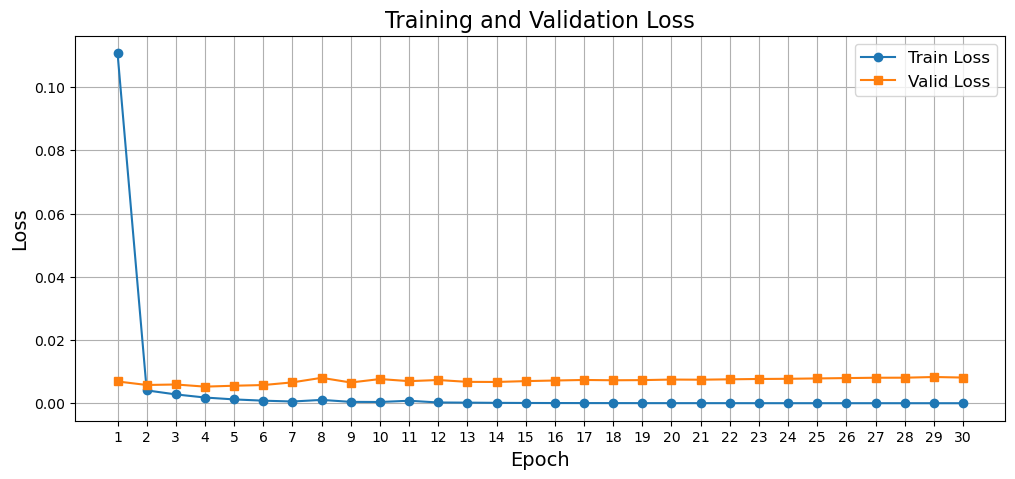

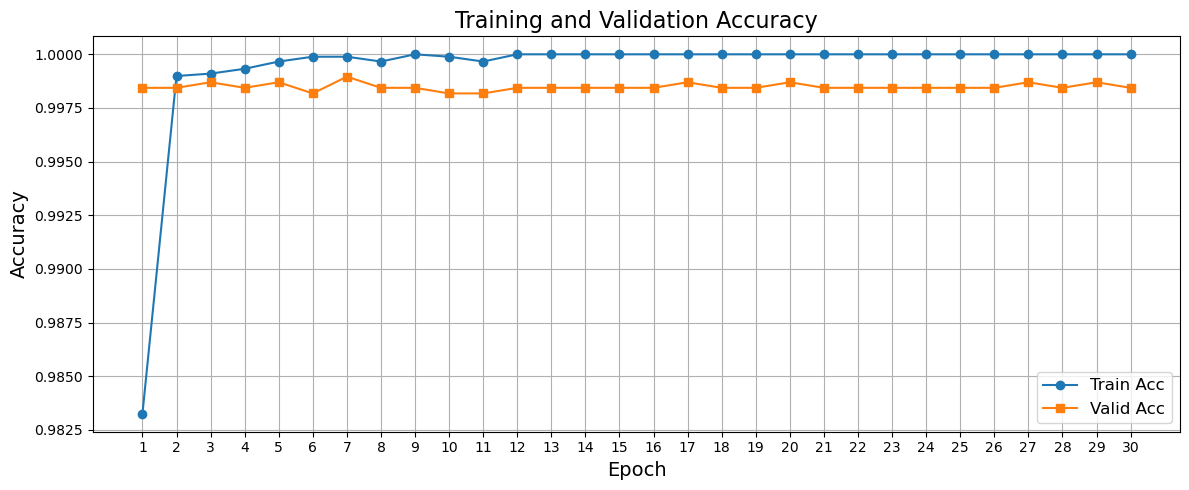

In [13]:
df_results = pd.DataFrame(results, index=range(1, EPOCHS+1))
plot_results(df_results)

In [14]:
model.load_state_dict(torch.load('simple_model.pt'))

model.eval()

test_loss, test_acc = validate(model, test_loader, criterion)
print(f'Test Loss: {test_loss:.3f}')
print(f'Test Accuracy: {test_acc*100:.2f}%')

C:\Users\aless\AppData\Local\Temp\ipykernel_25980\1023703335.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('simple_model.pt'))


Evaluating:   0%|          | 0/34 [00:00<?, ?it/s]

Test Loss: 0.001
Test Accuracy: 99.95%


Image selected: 1


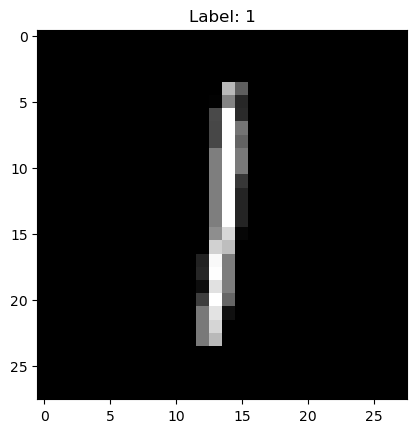


Number of pixels: 784
Pixel values (first 20): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

--- Generating constraints for LP ---
x_0 >= bias0 + 0.000000;
x_0 <= bias0 + 0.013000;
x_1 >= bias0 + 0.000000;
x_1 <= bias0 + 0.013000;
x_2 >= bias0 + 0.000000;
x_2 <= bias0 + 0.013000;
x_3 >= bias0 + 0.000000;
x_3 <= bias0 + 0.013000;
x_4 >= bias0 + 0.000000;
x_4 <= bias0 + 0.013000;
x_5 >= bias0 + 0.000000;
x_5 <= bias0 + 0.013000;
x_6 >= bias0 + 0.000000;
x_6 <= bias0 + 0.013000;
x_7 >= bias0 + 0.000000;
x_7 <= bias0 + 0.013000;
x_8 >= bias0 + 0.000000;
x_8 <= bias0 + 0.013000;
x_9 >= bias0 + 0.000000;
x_9 <= bias0 + 0.013000;
x_10 >= bias0 + 0.000000;
x_10 <= bias0 + 0.013000;
x_11 >= bias0 + 0.000000;
x_11 <= bias0 + 0.013000;
x_12 >= bias0 + 0.000000;
x_12 <= bias0 + 0.013000;
x_13 >= bias0 + 0.000000;
x_13 <= bias0 + 0.013000;
x_14 >= bias0 + 0.000000;
x_14 <= bias0 + 0.013000;
x_15 >= bias0 + 0.000000;
x_15 <= bias0 + 0.013000;
x_16 >= bias0 + 0.000000;
x_16 <= bias0

In [15]:
# Generate LP constraints for a specific test image
dataiter = iter(test_loader) 
images, labels = next(dataiter)

idx = 34
img_tensor = images[idx] 
label = labels[idx].item()

print(f"Image selected: {label}")

plt.imshow(img_tensor.squeeze(), cmap='gray')
plt.title(f"Label: {label}")
plt.show()

pixel_values = img_tensor.flatten().numpy()

print(f"\nNumber of pixels: {len(pixel_values)}")
print("Pixel values (first 20):", pixel_values[:20])

epsilon = 0.013
print("\n--- Generating constraints for LP ---")
for i, p in enumerate(pixel_values):

    lb = max(0.0, p - epsilon)
    ub = min(1.0, p + epsilon)
    
    print(f"x_{i} >= bias0 + {lb:.6f};")
    print(f"x_{i} <= bias0 + {ub:.6f};")

In [20]:
# Build x_lower/x_upper vectors for this image
epsilon = 0.05
try:
    pixel_values
except NameError:
    dataiter = iter(test_loader)
    images, labels = next(dataiter)
    idx = 34
    img_tensor = images[idx]
    pixel_values = img_tensor.flatten().numpy()

x0 = pixel_values.astype(float)
x_lower = np.clip(x0 - epsilon, 0.0, 1.0)
x_upper = np.clip(x0 + epsilon, 0.0, 1.0)

# Convert to comma-separated strings for CLI usage
x_lower_str = ",".join(f"{v:.6f}" for v in x_lower)
x_upper_str = ",".join(f"{v:.6f}" for v in x_upper)

print("x_lower (first 10):", x_lower[:10])
print("x_upper (first 10):", x_upper[:10])
print("\nCLI example:")
print(f"python .\\tropical_abstraction.py .\\simple_model.pt -xlb {x_lower_str} -xub {x_upper_str} -o mnist_img.lp")

x_lower (first 10): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
x_upper (first 10): [0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05]

CLI example:
python .\tropical_abstraction.py .\simple_model.pt -xlb 0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000

In [ ]:
with torch.no_grad():
    out = model(img_tensor.unsqueeze(0))
    print(f"Neural network output: {torch.sigmoid(out).item()}")

Output reale della rete: 0.9981145858764648


Raccolte 1 immagini misclassificate


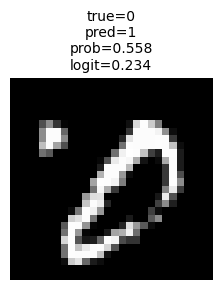

In [ ]:
# Find and show some misclassified images with probabilities and logits
misclassified = []
model.eval()
with torch.no_grad():
    for x, y in test_loader:
        logits = model(x)
        probs = torch.sigmoid(logits).squeeze(1)
        preds = (probs >= 0.5).long()
        mism = preds != y
        if mism.any():
            for img, true_lbl, pred_lbl, prob, logit in zip(
                x[mism], y[mism], preds[mism], probs[mism], logits.squeeze(1)[mism]
            ):
                misclassified.append(
                    {
                        "img": img.cpu(),
                        "true": int(true_lbl.item()),
                        "pred": int(pred_lbl.item()),
                        "prob": float(prob.item()),
                        "logit": float(logit.item()),
                    }
                )
                if len(misclassified) >= 20:
                    break
        if len(misclassified) >= 20:
            break

print(f"Collected {len(misclassified)} misclassified images")

# Visualize the first n misclassified images
n_show = min(20, len(misclassified))
fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3))
if n_show == 1:
    axes = [axes]
for ax, sample in zip(axes, misclassified[:n_show]):
    ax.imshow(sample["img"].squeeze().numpy(), cmap="gray")
    ax.axis("off")
    ax.set_title(
        f"true={sample['true']}\npred={sample['pred']}\nprob={sample['prob']:.3f}\nlogit={sample['logit']:.3f}",
        fontsize=10,
    )
plt.tight_layout()
plt.show()